In [3]:
import numpy as np;
import pandas as pd

In [72]:
courses=pd.read_csv('courses.csv')
students=pd.read_csv('students.csv')
nov=pd.read_csv('reg-month1.csv')
dec=pd.read_csv('reg-month2.csv')
delivery=pd.read_csv('deliveries.csv')
matches=pd.read_csv('matches.csv')

In [5]:
#pd.concat
regs =pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [6]:
#MULTI INDEX DATAFRAME
multi =pd.concat([nov,dec],keys=['NOV','DEC'])
multi.loc[('NOV',0)]

student_id    23
course_id      1
Name: (NOV, 0), dtype: int64

In [7]:
#MERGE(inner join, left join, right join, outer join)

In [12]:
#inner join
students.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [16]:
courses.merge(regs,how = 'left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [17]:
#right join

students.merge(regs,how = 'right' , on ='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [18]:
#outer join
students.merge(regs,how='outer',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,1,Kailash Harjo,23.0,6.0
2,1,Kailash Harjo,23.0,10.0
3,1,Kailash Harjo,23.0,9.0
4,2,Esha Butala,1.0,5.0
5,3,Parveen Bhalla,3.0,3.0
6,3,Parveen Bhalla,3.0,5.0
7,4,Marlo Dugal,14.0,NaN
8,5,Kusum Bahri,6.0,NaN
9,6,Lakshmi Contractor,10.0,NaN


In [23]:
#Find total Revenue granted
total = regs.merge(courses,how='inner',on='course_id')['price'].sum()
total

np.int64(154247)

In [29]:
#find month by month revenue
temp_df = pd.concat([nov,dec],keys=['NOV','DEC']).reset_index()
temp_df.merge(courses,on='course_id').groupby('level_0')['price'].sum()

level_0
DEC    65072
NOV    89175
Name: price, dtype: int64

In [37]:
#print the registration table 
# cols- > name -> course -> price

regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

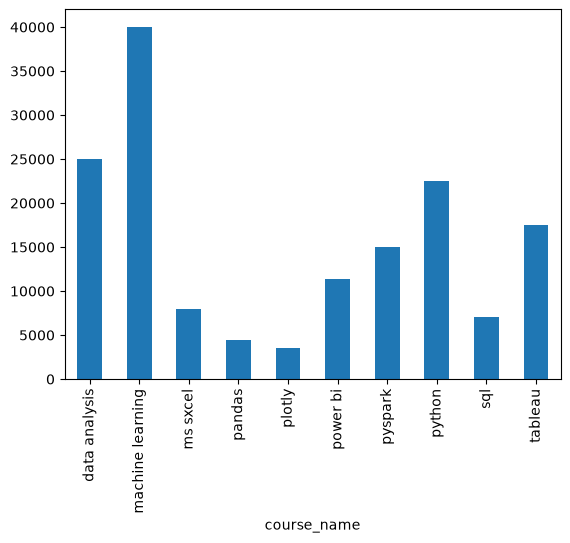

In [41]:
#plot bar chart for revenue/course
regs.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [44]:
#find the students who enrolled in both monthws
common = np.intersect1d(nov['student_id'],dec['student_id'])
students[students['student_id'].isin(common)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [47]:
#find course that got no enrollment

cns = np.setdiff1d(courses['course_id'],regs['course_id'])
courses[courses['course_id'].isin(cns)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [57]:
#print the students name -> partner name for all enrolled students
#self join hi bolte h

students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [61]:
#find 3 top students who did most number enrollements
regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: name, dtype: int64

In [66]:
#find 3 top students who spent most amount of money on courses
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

In [68]:
# #Alternate syntax of marge 
# pd.merge(students,regs,how='inner',on='student_id')

In [78]:
#ipl problem
#find top 3 player with highest sixes/match ratio
temp_df = delivery.merge(matches,left_on='match_id',right_on='id')

In [80]:
six_df= temp_df[temp_df['batsman_runs'] == 6]

In [82]:
#stadium -> total sixes
num_sixes = six_df.groupby('venue')['venue'].count()

In [87]:
num_match = matches['venue'].value_counts()

In [92]:
(num_sixes/num_match).sort_values(ascending=False).head(10)

venue
Holkar Cricket Stadium                                 17.600000
M Chinnaswamy Stadium                                  13.227273
Sharjah Cricket Stadium                                12.666667
Himachal Pradesh Cricket Association Stadium           12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    11.727273
Wankhede Stadium                                       11.526316
De Beers Diamond Oval                                  11.333333
Maharashtra Cricket Association Stadium                11.266667
JSCA International Stadium Complex                     10.857143
Sardar Patel Stadium, Motera                           10.833333
dtype: float64